 ##  Car sales in Norway - emissions and trends
### From lecture 02 with car sales in Norway, we worked with one dataset, however there were some more that you downloaded from kaggle. In this exercise, work with this dataset norway_new_car_sales_by_month.csv

  a) Do some EDA with info, find out column names, shape of dataset, describe method to get summary descriptive statistics.

  b) Draw a line chart of quantity for each year. Is there a year that should be skipped?

  c) Draw a line chart of average CO2 emissions for same years that as in b)

  d) Draw a line chart of all years and months for import

  e) Draw a line chart of all years and months for average CO2 emissions

  f) Draw a line chart of all years and months for electric cars import

  g) Draw a line chart of average diesel share per year

  h) Discuss some findings with a friend based on this dataset, and do plot more graphs

In [ ]:
# 0 a) Do some EDA with info, find out column names, shape of dataset, describe method to get summary descriptive statistics.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("norway_new_car_sales_by_month.csv")

df.head()

,Year,Month,Quantity,Quantity_YoY,Import,Import_YoY,Used,Used_YoY,Avg_CO2,Bensin_Co2,Diesel_Co2,Quantity_Diesel,Diesel_Share,Diesel_Share_LY,Quantity_Hybrid,Quantity_Electric,Import_Electric
0,2007,1,12685,5227,2276,257,NaN,NaN,152,155,152,10072,79.4,52.5,NaN,NaN,NaN
1,2007,2,9793,2448,1992,-89,NaN,NaN,156,159,155,7222,73.7,47.4,NaN,NaN,NaN
2,2007,3,11264,1445,2626,45,NaN,NaN,159,161,158,7965,70.7,48.1,NaN,NaN,NaN
3,2007,4,8854,504,2220,-130,NaN,NaN,160,165,158,6116,69.1,48.4,NaN,NaN,NaN
4,2007,5,12007,1592,2881,7,NaN,NaN,160,163,159,8519,71.0,49.1,NaN,NaN,NaN


In [2]:
df.columns

Index(['Year', 'Month', 'Quantity', 'Quantity_YoY', 'Import', 'Import_YoY',
       'Used', 'Used_YoY', 'Avg_CO2', 'Bensin_Co2', 'Diesel_Co2',
       'Quantity_Diesel', 'Diesel_Share', 'Diesel_Share_LY', 'Quantity_Hybrid',
       'Quantity_Electric', 'Import_Electric'],
      dtype='object')

In [3]:
df.shape

(121, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               121 non-null    int64  
 1   Month              121 non-null    int64  
 2   Quantity           121 non-null    int64  
 3   Quantity_YoY       121 non-null    int64  
 4   Import             121 non-null    int64  
 5   Import_YoY         121 non-null    int64  
 6   Used               61 non-null     float64
 7   Used_YoY           49 non-null     float64
 8   Avg_CO2            121 non-null    int64  
 9   Bensin_Co2         121 non-null    int64  
 10  Diesel_Co2         121 non-null    int64  
 11  Quantity_Diesel    121 non-null    int64  
 12  Diesel_Share       121 non-null    float64
 13  Diesel_Share_LY    121 non-null    float64
 14  Quantity_Hybrid    73 non-null     float64
 15  Quantity_Electric  73 non-null     float64
 16  Import_Electric    53 non-

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,121.0,2011.545455,2.915476,2007.0,2009.0,2012.0,2014.0,2017.0
Month,121.0,6.454545,3.488075,1.0,3.0,6.0,9.0,12.0
Quantity,121.0,11134.297521,1752.046397,5353.0,10250.0,11385.0,12337.0,14207.0
Quantity_YoY,121.0,392.586777,1789.539953,-4548.0,-526.0,493.0,1445.0,5227.0
Import,121.0,2204.371901,573.127896,1048.0,1812.0,2263.0,2625.0,3768.0
Import_YoY,121.0,-135.049587,545.395787,-1810.0,-495.0,-114.0,162.0,1334.0
Used,61.0,36864.737705,4230.548664,24106.0,34212.0,37079.0,39797.0,44106.0
Used_YoY,49.0,973.122449,2728.915662,-6261.0,-392.0,855.0,2708.0,5896.0
Avg_CO2,121.0,129.520661,22.719338,84.0,110.0,132.0,151.0,162.0
Bensin_Co2,121.0,133.735537,17.094233,94.0,120.0,131.0,150.0,165.0


In [ ]:
# 0  b) Draw a line chart of quantity for each year. Is there a year that should be skipped?

import duckdb

df_quantity_year = duckdb.query("""--sql
    SELECT
    Year,
    SUM(Quantity) AS Sales
    FROM
    df
    GROUP BY 
    Year
    ORDER BY 
    Year
"""
).df().set_index("Year")
df_quantity_year

,Sales
Year,
2007,129195.0
2008,110617.0
2009,98675.0
2010,127754.0
2011,138345.0
2012,137967.0
2013,142151.0
2014,144202.0
2015,150686.0


In [ ]:
# Slicar bort sista året pga datan för 2017 inte är komplett
df_quantity_year = df_quantity_year.iloc[:-1]
df_quantity_year

,Sales
Year,
2007,129195.0
2008,110617.0
2009,98675.0
2010,127754.0
2011,138345.0
2012,137967.0
2013,142151.0
2014,144202.0
2015,150686.0


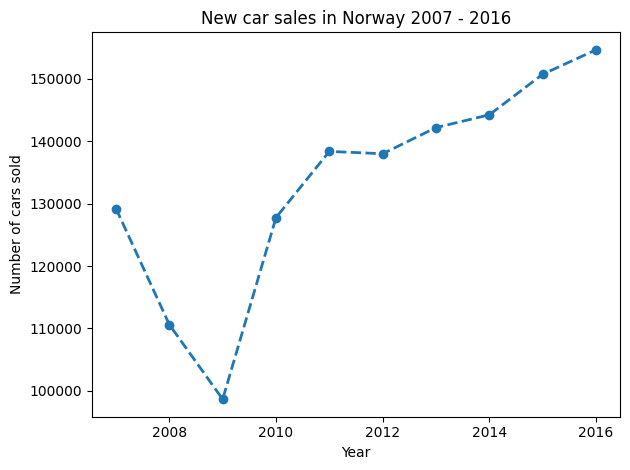

In [15]:
ax =df_quantity_year.plot(title = "New car sales in Norway 2007 - 2016",
                      xlabel="Year",
                      ylabel = "Number of cars sold",
                      style ="--o",
                      linewidth= 2
                      )

ax.legend().remove()
fig = ax.get_figure()
fig.tight_layout()

In [17]:
# 0 c) Draw a line chart of average CO2 emissions for same years that as in b

df = df.iloc[:-1]
df

,Year,Month,Quantity,Quantity_YoY,Import,Import_YoY,Used,Used_YoY,Avg_CO2,Bensin_Co2,Diesel_Co2,Quantity_Diesel,Diesel_Share,Diesel_Share_LY,Quantity_Hybrid,Quantity_Electric,Import_Electric
0,2007,1,12685,5227,2276,257,NaN,NaN,152,155,152,10072,79.4,52.5,NaN,NaN,NaN
1,2007,2,9793,2448,1992,-89,NaN,NaN,156,159,155,7222,73.7,47.4,NaN,NaN,NaN
2,2007,3,11264,1445,2626,45,NaN,NaN,159,161,158,7965,70.7,48.1,NaN,NaN,NaN
3,2007,4,8854,504,2220,-130,NaN,NaN,160,165,158,6116,69.1,48.4,NaN,NaN,NaN
4,2007,5,12007,1592,2881,7,NaN,NaN,160,163,159,8519,71.0,49.1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2016,8,13232,628,1485,-513,42645.0,4522.0,93,117,132,3837,29.0,38.2,3676.0,2014.0,494.0
116,2016,9,13854,1433,1526,-373,42780.0,236.0,88,98,128,3838,27.7,39.3,3991.0,2629.0,517.0
117,2016,10,11932,-1265,1365,-443,39797.0,-1611.0,91,98,127,3544,29.7,39.7,3209.0,1861.0,486.0
118,2016,11,13194,594,1305,-233,39721.0,2246.0,88,100,128,3892,29.5,39.7,3181.0,2567.0,502.0


In [19]:
df_co2_year = duckdb.query("""--sql
    SELECT
        Year,
        SUM(Avg_CO2) AS "Average CO2 emission"
    From
        df
    GROUP BY
        Year
    ORDER BY
        Year
""").df()

df_co2_year

,Year,Average CO2 emission
0,2007,1908.0
1,2008,1896.0
2,2009,1811.0
3,2010,1688.0
4,2011,1608.0
5,2012,1559.0
6,2013,1476.0
7,2014,1325.0
8,2015,1197.0
9,2016,1120.0


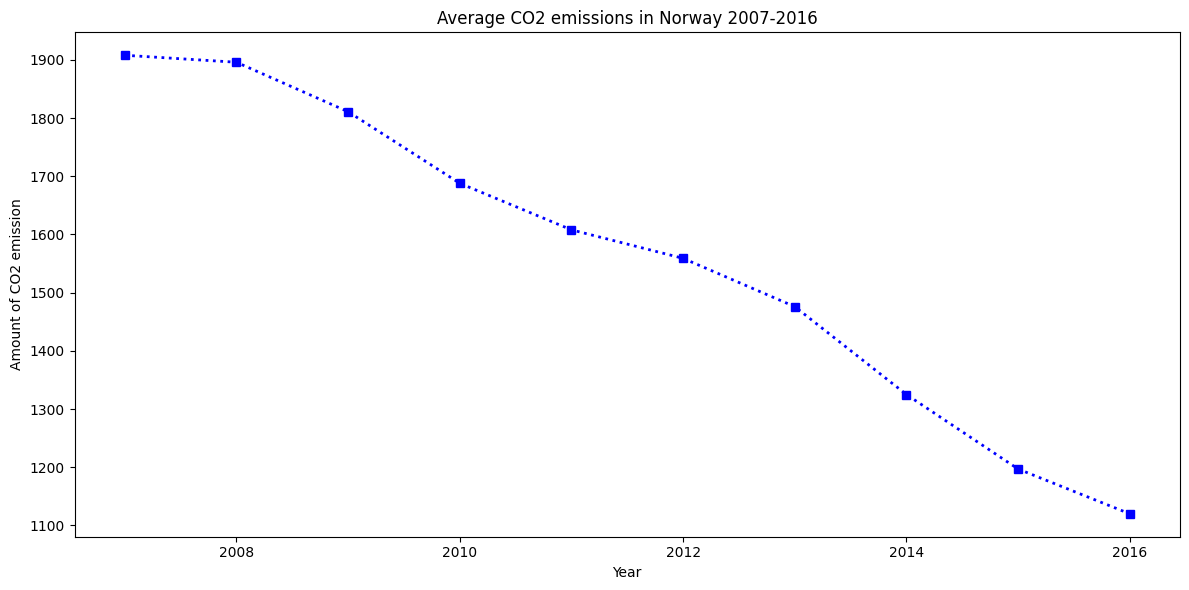

In [26]:
fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(
    df_co2_year["Year"],
    df_co2_year["Average CO2 emission"],
    color='blue',           # färg på linjen
    linestyle=':',         # typ av linje ('-', '--', ':', '-.')
    linewidth=2,          # tjocklek på linjen
    marker='s',          # markör för datapunkter ('o', 's', '^', etc.)
    markersize=6        # storlek på markörerna
)

ax.set(
    title=f"Average CO2 emissions in Norway {df_co2_year['Year'].min()}-{df_co2_year['Year'].max()}",
    xlabel = "Year",
    ylabel = "Amount of CO2 emission"
)

fig.tight_layout()

<Axes: title={'center': 'The total number of cars imported to Norway between 2007-2016'}, xlabel='Date', ylabel='Number of imported cars'>

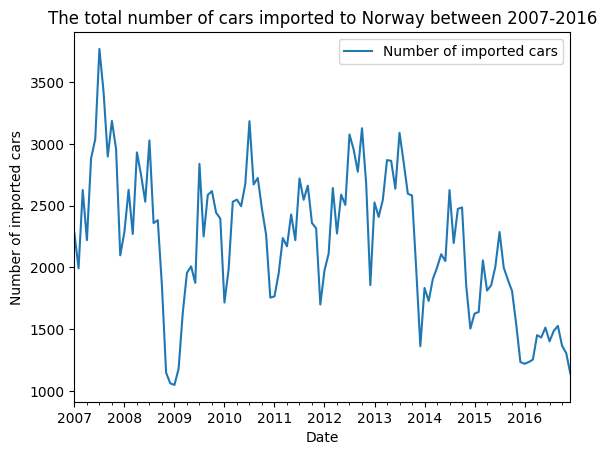

In [33]:
# 0 d) Draw a line chart of all years and months for import

df_import = duckdb.query("""--sql
    SELECT
        Year,
        Month,
        SUM(Import) AS "Number of imported cars"
    FROM
        df
    GROUP BY    
        Year,
        Month
    ORDER BY    
        Year, Month
""").df()

df_import = (df_import
    .assign(Date=pd.to_datetime(df_import["Year"].astype(str) + '-' + df_import["Month"].astype(str), format="%Y-%m"))
    .drop(columns=["Year", "Month"])
    .set_index("Date")
)
df_import.plot(title=f"The total number of cars imported to Norway between {df_co2_year['Year'].min()}-{df_co2_year['Year'].max()}",
               xlabel = "Date",
               ylabel = "Number of imported cars")

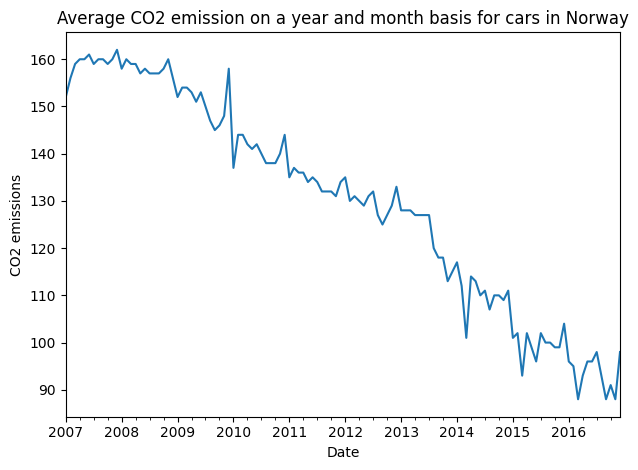

In [36]:
# e) Draw a line chart of all years and months for average CO2 emissions

df_c02_year_month = duckdb.query("""--sql
    SELECT
        Year,
        Month,
        SUM(Avg_CO2) AS "Average CO2 emission"
    FROM
        df
    GROUP BY    
        Year,
        Month
    ORDER BY    
        Year, Month
""").df()

df_c02_year_month = (df_c02_year_month
    .assign(Date=pd.to_datetime(df_c02_year_month["Year"].astype(str) + '-' + df_c02_year_month["Month"].astype(str), format="%Y-%m"))
    .drop(columns=["Year", "Month"])
    .set_index("Date"))

ax =df_c02_year_month.plot(title="Average CO2 emission on a year and month basis for cars in Norway",
                       xlabel="Date",
                       ylabel="CO2 emissions")
ax.legend().remove()
fig = ax.get_figure()
fig.tight_layout()

<Axes: title={'center': 'The total number of cars, and electrical cars imported to Norway between 2007-2016'}, xlabel='Date', ylabel='Number of imported cars'>

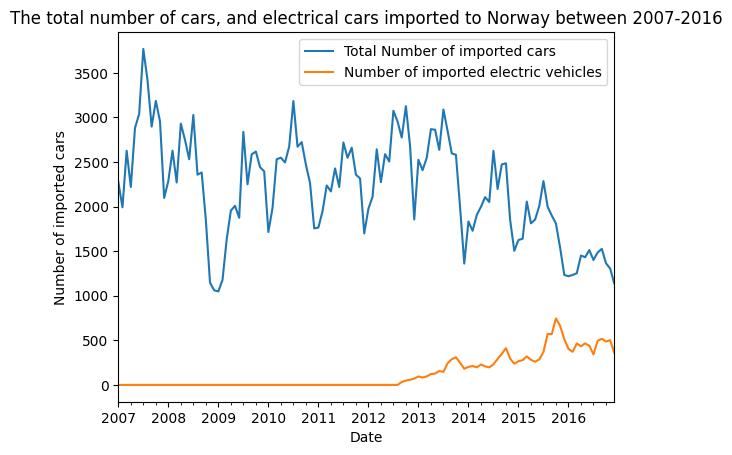

In [48]:
# 0 f) Draw a line chart of all years and months for electric cars 

df_ev_import = duckdb.query("""--sql
    SELECT
        Year,
        Month,
        SUM(Import) AS "Total Number of imported cars",
        SUM(Import_electric) AS "Number of imported electric vehicles"
    FROM
        df
    GROUP BY    
        Year,
        Month
    ORDER BY    
        Year, Month
""").df()
df_ev_import["Number of imported electric vehicles"] = df_ev_import["Number of imported electric vehicles"].fillna(0)

df_ev_import = (df_ev_import
    .assign(Date=pd.to_datetime(df_ev_import["Year"].astype(str) + '-' + df_ev_import["Month"].astype(str), format="%Y-%m"))
    .drop(columns=["Year", "Month"])
    .set_index("Date")
)

df_ev_import.plot(title=f"The total number of cars, and electrical cars imported to Norway between {df_co2_year['Year'].min()}-{df_co2_year['Year'].max()}",
               xlabel = "Date",
               ylabel = "Number of imported cars")

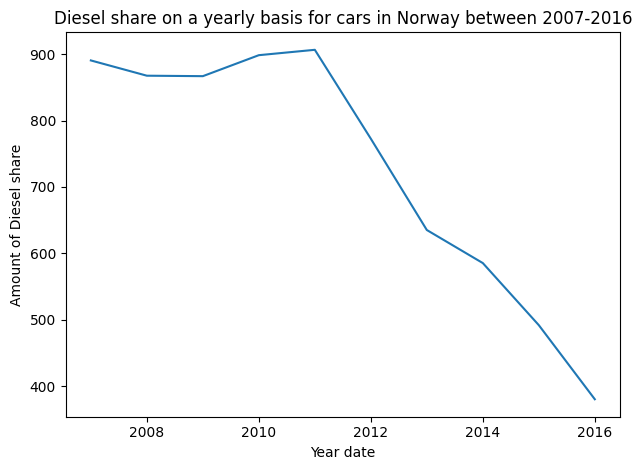

In [53]:
# 0 g) Draw a line chart of average diesel share per year

df_diesel_share = duckdb.query("""--sql
    SELECT
        Year,
        SUM(Diesel_Share) AS "Diesel Share"
    FROM
        df
    GROUP BY    
        Year
    ORDER BY    
        Year
""").df().set_index("Year")
ax= df_diesel_share.plot(title=f"Diesel share on a yearly basis for cars in Norway between {df_co2_year['Year'].min()}-{df_co2_year['Year'].max()}",
                     xlabel = "Year date",
                     ylabel = "Amount of Diesel share")

ax.legend().remove()
fig= ax.get_figure()
fig.tight_layout()